# 03_demotion_timeline

A structured tracker for the observational papers on lunar mini-magnetospheres,
built to support two figures in the literature review presentation:

- **Slide 3.1**, the demotion timeline: how confidence in the mini-magnetosphere
  framing rose and fell as instrumentation improved.
- **Slide 3.2**, "shielding is always partial": the measured exclusion fractions.

The intended figure is a dumbbell chart — one row per paper, two markers per row
(claimed structure scale, and the proton gyroradius at that paper's own field),
log length axis. Every pair points the same way: the gyroradius sits to the
right of the claimed structure, in every paper.

## The argument the data serves

Crustal anomalies are obstacles smaller than the scale on which solar wind ions
can respond. Electrons are magnetised; protons are not. Everything observed —
partial shielding, shock-like discontinuities, reflected protons,
electron-only reconnection — follows from that inequality.
The timeline is not monotonic. Claim strength peaks at Kurata 2005 (declarative
title, two magnetometer passes, no plasma instrument) and declines thereafter as
plasma and ion measurements arrive.

## Why the columns are shaped this way

Several columns exist to prevent the figure from lying:

- **`B_peak_nT` vs `B_paper_nT`** — the strongest field the paper reports at its
  own observation, versus the field it feeds into its own scale argument. These
  differ, and the difference is often the finding (Lin quotes 12 nT in his
  coherence criterion while observing 30 nT).
- **`L_basis` and `L_orientation`** — "structure scale" does not mean the same
  thing twice. Kurata's 30 km is a *vertical* lower bound set by spacecraft
  periapsis; Wieser's 360 km is a *horizontal* surface footprint imaged from
  200 km. Plotting both on one length axis without flagging this is the most
  attackable thing the figure could do.
- **`v_kms` and `v_basis`** — gyroradii are computed at each paper's own
  measured solar wind speed where quoted, nominal 400 km/s otherwise. Using a
  single speed throughout would break the like-for-like comparison; Halekas's
  event was 303 km/s.
- **`exclusion_pct` + `exclusion_species` + `exclusion_basis`** — the depletion
  numbers are not commensurable. Halekas is a normalised electron density drop;
  Wieser is an H-ENA flux reduction measured against an already-enhanced ring.
  The basis string carries more information than the number.
- **`alt_context`** — spacecraft altitude, structure altitude and the altitude
  at which a field value was modelled are three different things, and Wieser
  has all three in one row.

## Convention

Proton gyroradii use the **convective** speed, not the thermal speed. At the
nose, `B_n = 0` and the flow is normal, so the bulk drift projects fully onto
the perpendicular direction — this is geometry, not a comparison of magnitudes.
Protons complete a fraction of one orbit per crossing, so there is no gyrophase
averaging to justify a thermal value. Electrons, which complete hundreds, are a
different case.

`r_p_therm_km` is computed anyway, because the divergence between the two is
itself evidence: it runs a factor of ~9 under nominal conditions and ~21 at the
Halekas event, and the thermal substitution is what lets Lin's ~30 km criterion
look reasonable.

In [9]:
import numpy as np
import pandas as pd

# --- constants -------------------------------------------------------------
M_P    = 1.67262192e-27   # kg
Q_E    = 1.602176634e-19  # C
V_SW   = 400e3            # m/s, nominal convective (bulk) speed
T_P_EV = 10.0             # eV, nominal proton temperature
V_TH   = np.sqrt(2 * T_P_EV * Q_E / M_P)   # m/s, ~43.8 km/s
EPS0 = 8.8541878128e-12
C_L  = 2.99792458e8

def r_p(B_nT, v):
    """Proton gyroradius in km. B in nT, v in m/s."""
    if B_nT is None or np.isnan(B_nT):
        return np.nan
    return (M_P * v) / (Q_E * B_nT * 1e-9) / 1e3


def d_i(n_cm3):
    """Ion inertial length in km. n in cm^-3."""
    if n_cm3 is None or np.isnan(n_cm3):
        return np.nan
    n = n_cm3 * 1e6
    w_pi = np.sqrt(n * Q_E**2 / (EPS0 * M_P))
    return C_L / w_pi / 1e3

# --- schema ----------------------------------------------------------------
# B_peak_nT : strongest field the paper reports at its own observation.
#             Use THIS for r_p, so the comparison is like-for-like.
# B_paper_nT: the field the paper plugs into its own scale argument, if any.
#             Differs from B_peak - that difference is often the finding.
# L_basis   : how the scale was arrived at. Will not mean the same thing twice.

COLS = ["paper", "year", "alt_min_km", "alt_max_km", "alt_context",
        "B_peak_nT", "B_peak_context", "B_paper_nT", "B_paper_context",
        "L_min_km", "L_max_km", "L_basis", "L_orientation",
        "v_kms", "v_basis", "n_cm3", "T_p_eV", "B_imf_nT", "P_sw_nPa",
        "instrument_class", "ions_measured", "N_evidence",
        "name_used", "exclusion_pct", "exclusion_species", "exclusion_basis"]

rows = [
    dict(paper="Lin", year=1998,
         alt_min_km=100.0, alt_max_km=100.0,
         alt_context="spacecraft",
         B_peak_nT=30.0,
         B_peak_context="peak |B| in shock enhancement, Fig 3; contours at 20 and 27 nT",
         B_paper_nT=12.0,
         B_paper_context="field in his coherence criterion - source of 12 nT never stated",
         L_min_km=100.0, L_max_km=500.0,
         L_basis="abstract assertion, 'across'; inherited from crustal patch size, "
                 "not a measured boundary. NOT the 100 km altitude.",
         L_orientation="horizontal",
         v_kms=400.0, v_basis="nominal - no local SW velocity quoted",
         n_cm3=np.nan, T_p_eV=np.nan, B_imf_nT=10.0, P_sw_nPa=3.0,
         instrument_class="field+electrons",
         ions_measured=False,
         N_evidence="4 of 5 consecutive orbits",
         name_used="miniature magnetosphere / limb shock vs limb compression (hedged in text)",
         exclusion_pct=np.nan, exclusion_species=None,
         exclusion_basis="not measured; shock inferred from electron energization + 2.5 Hz whistlers"),

    dict(paper="Kurata", year=2005,
         alt_min_km=26.0, alt_max_km=29.1,
         alt_context="spacecraft",
         B_peak_nT=35.0,
         B_peak_context="peak observed total intensity, day 68",
         B_paper_nT=np.nan,
         B_paper_context="no scale argument made",
         L_min_km=30.0, L_max_km=np.nan,
         L_basis="spacecraft altitude - lower bound, no boundary crossing",
         L_orientation="vertical",
         v_kms=400.0, v_basis="nominal - only P_sw quoted",
         n_cm3=np.nan, T_p_eV=np.nan, B_imf_nT=np.nan, P_sw_nPa=3.5,
         instrument_class="field",
         ions_measured=False,
         N_evidence="2 passes",
         name_used="mini-magnetosphere (declarative, in title)",
         exclusion_pct=np.nan, exclusion_species=None,
         exclusion_basis="not measured; no plasma instrument"),

    dict(paper="Halekas", year=2008,
         alt_min_km=30.0, alt_max_km=36.0,
         alt_context="spacecraft; 30 km at 2nd cavity (17:33), higher at 1st (15:43) - "
                     "abstract's '30 km' is not both orbits",
         B_peak_nT=18.0,
         B_peak_context="peak |B| in 2nd cavity, read off Fig 3 (not in text); 1st cavity ~15 nT",
         B_paper_nT=np.nan,
         B_paper_context="no field-based scale argument; scaling argued via d_i instead",
         L_min_km=np.nan, L_max_km=np.nan,
         L_basis="no structure size quoted. Cavity ~10 deg downstream of CA centre - "
                 "that is a displacement, not an extent.",
         L_orientation=None,
         v_kms=303.0, v_basis="Wind SWE, time-shifted; 96th pct (low)",
         n_cm3=15.8, T_p_eV=1.11, B_imf_nT=2.36, P_sw_nPa=np.nan,
         instrument_class="field+electrons",
         ions_measured=False,
         N_evidence="2 consecutive orbits in ~7 months; null argued from ~1000 wake voids",
         name_used="'what may be' inner region of a mini-magnetosphere (interrogative title)",
         exclusion_pct=95.0, exclusion_species="electron",
         exclusion_basis="n/n_0 bottoms at ~0.05 both cavities (Fig 3); 3-d kappa-fit moments "
                         "NORMALISED to SW average, relative not absolute"),

    dict(paper="Wieser", year=2010,
         alt_min_km=200.0, alt_max_km=200.0,
         alt_context="spacecraft. Structure imaged AT SURFACE; field quoted at 30 km. "
                     "Three different altitudes in one row - do not plot 200 km as "
                     "the interaction altitude.",
         B_peak_nT=np.nan,
         B_peak_context="no magnetometer in this analysis",
         B_paper_nT=20.0,
         B_paper_context="imported: LP-derived model value at 30 km alt "
                         "(Mitchell 2008; Richmond & Hood 2008). 100 nT at surface.",
         L_min_km=360.0, L_max_km=360.0,
         L_basis="ENA surface footprint diameter, 150-600 eV band; "
                 "+300 km thick enhanced-flux annulus outside it",
         L_orientation="horizontal",
         v_kms=333.0, v_basis="from measured mean SW proton energy 580 eV. "
                              "NB paper computes r_p using 1 keV, giving 100 km not 174 km.",
         n_cm3=np.nan, T_p_eV=np.nan, B_imf_nT=5.0, P_sw_nPa=1.25,
         instrument_class="ENA+ions",
         ions_measured=True,
         N_evidence="1 day (17 Jun 2009), consistent on each anomaly pass",
         name_used="mini-magnetosphere, declarative + 'direct proof'; "
                   "but 'partial void' in same abstract",
         exclusion_pct=50.0, exclusion_species="H ENA proxy for proton",
         exclusion_basis="ENA flux reduction 150-600 eV, relative to SURROUNDING ENHANCED RING "
                         "not undisturbed terrain - true depletion is smaller. "
                         "Depletion vanishes below 100 eV."),

    dict(paper="Lue", year=2011,
         alt_min_km=100.0, alt_max_km=100.0,
         alt_context="spacecraft, polar orbit. Deflection mapped to SURFACE via "
                     "line-of-sight at 63 deg from nadir - justified by r_p (1300 km) "
                     "being large vs altitude, i.e. the ballistic assumption is the "
                     "same inequality that undermines the fluid picture.",
         B_peak_nT=np.nan,
         B_peak_context="no magnetometer",
         B_paper_nT=30.0,
         B_paper_context="range 3-30 nT at 30 km alt, imported from Purucker 2008 "
                         "(LP-derived). Weak anomalies <3 nT also show deflection.",
         L_min_km=1000.0, L_max_km=np.nan,
         L_basis="coherent anomaly CLUSTER scale, not single anomaly. Para 17: "
                 "exceeds single-anomaly r_p, which is how the obstacle picture "
                 "is rescued - by rescaling out of the regime that made it mini.",
         L_orientation="horizontal",
         v_kms=380.0, v_basis="quoted for their 1300 km r_p estimate in IMF ~3 nT; "
                              "600 eV used for the 110-1100 km anomaly-field range",
         n_cm3=np.nan, T_p_eV=600.0, B_imf_nT=3.0, P_sw_nPa=np.nan,
         instrument_class="ions",
         ions_measured=True,
         N_evidence="15 days, >180 deg longitude, statistical (far side)",
         name_used="magnetosphere-like obstacle (cluster scale only); "
                   "'magnetic reflection for protons should not occur' at single-anomaly scale",
         exclusion_pct=10.0, exclusion_species="proton, direct",
         exclusion_basis="deflected proton flux / WIND incident flux. STRATIFIED BY AREA: "
                         "~1% whole far side, ~10% anomaly regions (10% of area), "
                         "~50% strongest anomalies (0.1% of area). Headline value here is "
                         "the anomaly-region average. All three inherit an assumed 0.15 sr "
                         "solid angle from a 22 deg spread temperature fit."),
                        
dict(paper="Saito", year=2012,
         alt_min_km=25.0, alt_max_km=25.0,
         alt_context="perilune, 23 Apr 2009, South Pole Aitken. Lowest in the set. "
                     "Second event at ~100 km (29 May 2008) shows same signature weakly. "
                     "Interaction region they cannot reach is BELOW 25 km.",
         B_peak_nT=16.0,
         B_peak_context="measured at Kaguya by LMAG during the 25 km event",
         B_paper_nT=45.0,
         B_paper_context="field REQUIRED to stand off 350 km/s at 4 cm^-3. Not measured. "
                         "Measured was 16 nT. Rescued by assuming stronger field below "
                         "spacecraft - same move as Kurata's 'slightly below the magnetopause', "
                         "same group, better instruments.",
         L_min_km=100.0, L_max_km=100.0,
         L_basis="crossing duration ~60 s x orbital speed 1.6 km/s. First L in the set "
                 "that is DERIVED from data rather than asserted or bounded.",
         L_orientation="horizontal",
         v_kms=350.0, v_basis="measured solar wind bulk velocity, Fig 6(d); "
                              "reflected population ~200 km/s",
         n_cm3=4.0, T_p_eV=np.nan, B_imf_nT=np.nan, P_sw_nPa=np.nan,
         instrument_class="field+electrons+ions+mass",
         ions_measured=True,
         N_evidence="13 events for the E-field correlation (23 Apr 2009); signature seen in "
                    "'almost all' encounters at 25 km",
         name_used="'mini-magnetosphere' IN SCARE QUOTES; observation explicitly placed "
                   "ABOVE/OUTSIDE it - incident SW still at high density and velocity at 25 km",
         exclusion_pct=50.0, exclusion_species="ion, direct",
         exclusion_basis="reflected ion density / incident SW ion density (IMA vs IEA velocity "
                         "moments), peak value, single event. Third independent ~50% ceiling "
                         "after Wieser (ENA) and Lue (deflected flux) - different quantities, "
                         "same bound."),

dict(paper="Vorburger", year=2012,
         alt_min_km=100.0, alt_max_km=200.0,
         alt_context="TWO orbits in the dataset: 100 km circular, raised to 200 km end of "
                     "May 2009. Sector-3 surface footprint 83x11 km^2 at 100 km, "
                     "168x23 km^2 at 200 km - factor 2, and the footprint argument is "
                     "what drives their sector cut. Field map is at 30 km throughout.",
         B_peak_nT=np.nan,
         B_peak_context="no magnetometer; CENA only. SWIM deliberately not used "
                        "(power constraints, non-concurrent), WIND used instead.",
         B_paper_nT=30.0,
         B_paper_context="MAP MAXIMUM at 30 km (Richmond & Hood 2008) - used for their "
                         "gyroradius argument. Their own observation tables span "
                         "4.0-17.5 nT. The scale ratios are best cases at the strongest "
                         "field on the Moon.",
         L_min_km=np.nan, L_max_km=np.nan,
         L_basis="expressed IN GYRORADII, not km: Gerasimovich >=2-3 r_p, SPA >=6, "
                 "Serenitatis antipode >=2.5, location 8 >=1. First paper to state L "
                 "as a scale ratio. Recompute at their median field ~8 nT: r_p = 570 km, "
                 "so Gerasimovich becomes a fraction of one gyroradius.",
         L_orientation="horizontal",
         v_kms=439.0, v_basis="quoted for their r_p = 152 km at 1 keV in 30 nT. "
                              "1 keV again, as in Wieser - not a measured mean.",
         n_cm3=5.0, T_p_eV=np.nan, B_imf_nT=np.nan, P_sw_nPa=0.7,
         instrument_class="ENA",
         ions_measured=False,
         N_evidence="121 observations / 10 anomalies / 37 at Gerasimovich (32 with clear "
                    "void). LARGEST SAMPLE IN SET. But 4 of 9 usable locations show the "
                    "B-SE correlation, 3 show none, 2 have one point each (incl. Reiner "
                    "Gamma - Kurata's anomaly, unanalysable here).",
         name_used="minimagnetosphere, unhedged throughout - while stating that the "
                   "classical interaction does not apply at comparable-to-gyroradius scale",
         exclusion_pct=35.0, exclusion_species="H ENA proxy for proton",
         exclusion_basis="shielding efficiency = 1 - J_ENA/J_S, measured against a MODELLED "
                         "scattering function (Schaufelberger 2011), not an adjacent region "
                         "- methodological improvement on Wieser. Value here is approx median "
                         "of the Gerasimovich distribution; full range ~2-74%, typical "
                         "uncertainty 6-15 pp. Wieser's >50% sits in the upper tail AT THE "
                         "SAME ANOMALY. Confound acknowledged: reduction could be shielding "
                         "or mineralogical backscatter variation, inseparable."),

dict(paper="Xie", year=2021,
         alt_min_km=0.0, alt_max_km=0.0,
         alt_context="SURFACE. ASAN on Yutu-2 rover, 177.6E 45.4S, at the SE EDGE of the "
                     "Imbrium antipode anomaly (centred 162E 33S, radius >600 km). "
                     "Bottom of the altitude axis. ARTEMIS used only as an upstream SW "
                     "monitor, not as a second probe - still a single point.",
         B_peak_nT=np.nan,
         B_peak_context="no local magnetometer",
         B_paper_nT=np.nan,
         B_paper_context="field from Tsunakawa 2015 450-deg spherical harmonic model "
                         "(Fig 1a scale to 200 nT). Imported, not measured. No field-based "
                         "scale argument - the controlling parameter is d_i, not B.",
         L_min_km=600.0, L_max_km=np.nan,
         L_basis="TAIL length >600 km, required for CE-4 at the anomaly edge to be 'inside' "
                 "anything. Inferred backwards from the observation being shielded, not "
                 "measured. Same rescue as Lue's cluster scale: the object is enlarged "
                 "until the data fits inside it.",
         L_orientation="downstream",
         v_kms=500.0, v_basis="simulation Case 1 (typical ASAN conditions); per-interval "
                              "v and n from ARTEMIS. Cases span 250-500 km/s.",
         n_cm3=4.0, T_p_eV=np.nan, B_imf_nT=5.0, P_sw_nPa=np.nan,
         instrument_class="ENA (surface) + upstream monitor",
         ions_measured=False,
         N_evidence="46 intervals over 15 months (27 morning/upstream, 19 afternoon/"
                    "downstream). Quantitative shielding from FOUR downstream + two "
                    "upstream intervals. d_i<120 km threshold rests on n=4 plus 4 sim cases.",
         name_used="mini-magnetosphere, unhedged, in the title - while reporting no cavity, "
                   "no shock, deflection rather than exclusion, and no shielding in 1 of 4 cases",
         exclusion_pct=56.0, exclusion_species="H ENA proxy for proton",
         exclusion_basis="1 - eta_SW, where eta_SW = normalised downstream ENA flux / "
                         "normalised upstream flux at MATCHED incident angle and sun azimuth. "
                         "Dn1 57%, Dn2 48%, Dn3 64%, Dn4 -60% (eta=1.6, ENHANCEMENT). "
                         "Value here is mean of Dn1-3. Best control in the set: lunar "
                         "rotation reverses the geometry over the same regolith, so the "
                         "reference is the same instrument 12 h earlier. Only H ENAs "
                         ">100 eV (sputtered contamination below), so no absolute ratio."),
]

df = pd.DataFrame(rows).reindex(columns=COLS)

# --- derived ---------------------------------------------------------------
df["alt_mid_km"]   = df[["alt_min_km", "alt_max_km"]].mean(axis=1)
df["L_mid_km"]     = df[["L_min_km", "L_max_km"]].mean(axis=1)
df["v_ms"]         = df["v_kms"] * 1e3
df["r_p_conv_km"]  = df.apply(lambda r: r_p(r["B_peak_nT"], r["v_ms"]), axis=1)
df["r_p_paper_km"] = df.apply(lambda r: r_p(r["B_paper_nT"], r["v_ms"]), axis=1)
df["d_i_km"]       = df["n_cm3"].apply(d_i)
df["L_over_rp"]    = df["L_mid_km"] / df["r_p_conv_km"].fillna(df["r_p_paper_km"])

# papers' own quoted gyroradii, where they compute one
df.loc[df.paper == "Lin",    "r_p_quoted_km"] = 30.0     # thermal substitution
df.loc[df.paper == "Wieser", "r_p_quoted_km"] = 100.0    # 1 keV, not their measured 580 eV
df.loc[df.paper == "Lue",    "r_p_quoted_km"] = 605.0    # midpoint of 110-1100, 600 eV convective
df.loc[df.paper == "Vorburger", "r_p_recomputed_km"] = r_p(8.0, 439e3)  # Vorburger's scale ratios recomputed at their own observed median field rather than the map maximum they used, ~573 km

df.loc[df.paper == "Xie", "d_i_km"]           = 114.0   # sim Case 1; cases span 81-162
df.loc[df.paper == "Xie", "d_i_threshold_km"] = 120.0   # shielding only below this

# --- potential and Hall-scale columns --------------------------------------
df.loc[df.paper == "Saito", "potential_V"]     = 150.0
df.loc[df.paper == "Saito", "potential_basis"] = (
    "dE/q equal for protons and alphas AND matched to electron gain; "
    "E_idec = 0.98 E_eacc, r = 0.965 over 13 events. Only measured potential in the set.")
df.loc[df.paper == "Saito", "d_i_km"]          = 115.0   # their value, n = 4 cm^-3

df["r_p_quoted_note"] = df["paper"].map({
    "Lin":    "thermal speed implied; convective at 12 nT gives 348 km",
    "Wieser": "used 1 keV; their own measured mean was 580 eV -> 174 km",
    "Lue":    "600 eV bulk energy, convective convention correctly applied",
})

# self-checks
assert abs(r_p(12.0, 400e3) - 348) < 2, "Lin criterion field"
assert abs(r_p(35.0, 400e3) - 119) < 2, "Kurata peak field"
assert abs(r_p(18.0, 303e3) - 175) < 2, "Halekas cavity field"
assert abs(r_p(20.0, 333e3) - 174) < 2, "Wieser, at their own 580 eV not 1 keV"
assert abs(d_i(15.8)  - 57) < 1,        "Halekas d_i reproduces their 57 km"

df

,paper,year,alt_min_km,alt_max_km,alt_context,B_peak_nT,B_peak_context,B_paper_nT,B_paper_context,L_min_km,...,r_p_conv_km,r_p_paper_km,d_i_km,L_over_rp,r_p_quoted_km,r_p_recomputed_km,d_i_threshold_km,potential_V,potential_basis,r_p_quoted_note
0,Lin,1998,100.0,100.0,spacecraft,30.0,"peak |B| in shock enhancement, Fig 3; contours...",12.0,field in his coherence criterion - source of 1...,100.0,...,139.195799,347.989496,NaN,2.155237,30.0,NaN,NaN,NaN,NaN,thermal speed implied; convective at 12 nT giv...
1,Kurata,2005,26.0,29.1,spacecraft,35.0,"peak observed total intensity, day 68",NaN,no scale argument made,30.0,...,119.310684,NaN,NaN,0.251444,NaN,NaN,NaN,NaN,NaN,NaN
2,Halekas,2008,30.0,36.0,"spacecraft; 30 km at 2nd cavity (17:33), highe...",18.0,"peak |B| in 2nd cavity, read off Fig 3 (not in...",NaN,no field-based scale argument; scaling argued ...,NaN,...,175.734696,NaN,57.286861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Wieser,2010,200.0,200.0,spacecraft. Structure imaged AT SURFACE; field...,NaN,no magnetometer in this analysis,20.0,imported: LP-derived model value at 30 km alt ...,360.0,...,NaN,173.820753,NaN,2.071099,100.0,NaN,NaN,NaN,NaN,used 1 keV; their own measured mean was 580 eV...
4,Lue,2011,100.0,100.0,"spacecraft, polar orbit. Deflection mapped to ...",NaN,no magnetometer,30.0,"range 3-30 nT at 30 km alt, imported from Puru...",1000.0,...,NaN,132.236009,NaN,7.562237,605.0,NaN,NaN,NaN,NaN,"600 eV bulk energy, convective convention corr..."
5,Saito,2012,25.0,25.0,"perilune, 23 Apr 2009, South Pole Aitken. Lowe...",16.0,measured at Kaguya by LMAG during the 25 km event,45.0,field REQUIRED to stand off 350 km/s at 4 cm^-...,100.0,...,228.368107,81.197549,115.000000,0.437890,NaN,NaN,NaN,150.0,dE/q equal for protons and alphas AND matched ...,NaN
6,Vorburger,2012,100.0,200.0,"TWO orbits in the dataset: 100 km circular, ra...",NaN,no magnetometer; CENA only. SWIM deliberately ...,30.0,MAP MAXIMUM at 30 km (Richmond & Hood 2008) - ...,NaN,...,NaN,152.767389,101.835351,NaN,NaN,572.877708,NaN,NaN,NaN,NaN
7,Xie,2021,0.0,0.0,"SURFACE. ASAN on Yutu-2 rover, 177.6E 45.4S, a...",NaN,no local magnetometer,NaN,field from Tsunakawa 2015 450-deg spherical ha...,600.0,...,NaN,NaN,114.000000,NaN,NaN,NaN,120.0,NaN,NaN,NaN


Plotting the figure:

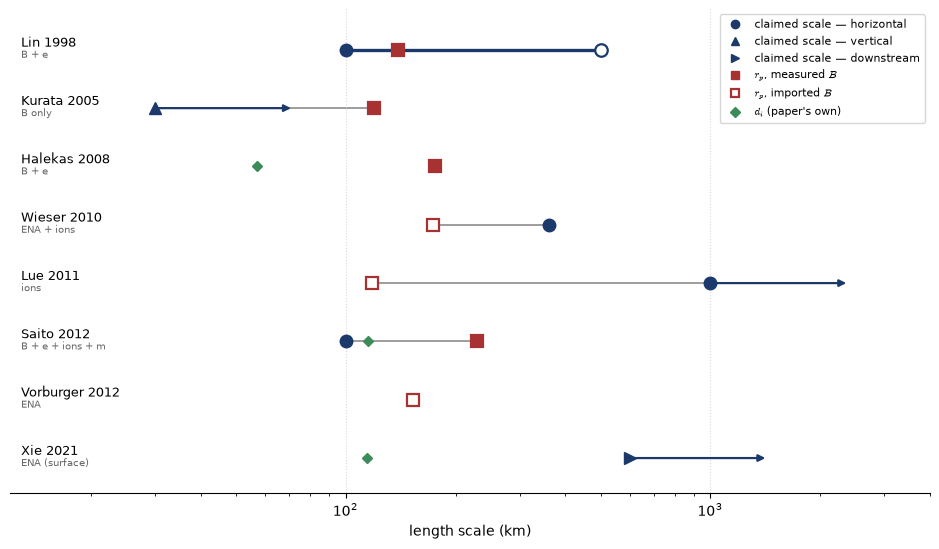

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'sans serif',
    'mathtext.fontset': 'cm',
    'font.size': 10,
})

M_P, Q_E = 1.67262192e-27, 1.602176634e-19

def r_p(B_nT, v_kms):
    """Proton gyroradius, km. Convective convention."""
    if B_nT is None or v_kms is None:
        return None
    return (M_P * v_kms * 1e3) / (Q_E * B_nT * 1e-9) / 1e3

# paper, L_min, L_max, L is lower bound, orientation, B_nT, v_kms, B source, instrument, d_i
ROWS = [
    ("Lin 1998",        100.,  500., False, "horiz",  30., 400., "measured", "B + e",              None),
    ("Kurata 2005",      30.,  None, True,  "vert",   35., 400., "measured", "B only",             None),
    ("Halekas 2008",    None,  None, False, None,     18., 303., "measured", "B + e",              57.),
    ("Wieser 2010",     360.,  360., False, "horiz",  20., 333., "imported", "ENA + ions",         None),
    ("Lue 2011",       1000.,  None, True,  "horiz",  30., 339., "imported", "ions",               None),
    ("Saito 2012",      100.,  100., False, "horiz",  16., 350., "measured", "B + e + ions + m",   115.),
    ("Vorburger 2012",  None,  None, False, None,     30., 439., "imported", "ENA",                None),
    ("Xie 2021",        600.,  None, True,  "down",   None, None, None,      "ENA (surface)",      114.),
]

L_MARKER = {"horiz": "o", "vert": "^", "down": ">"}
C_L, C_RP, C_DI = "#1b3a6b", "#a83232", "#3c8c5a"

fig, ax = plt.subplots(figsize=(9.5, 5.6))

for i, (name, Lmin, Lmax, onesided, orient, B, v, Bsrc, instr, di) in enumerate(ROWS):
    y = -i
    rp = r_p(B, v)

    # connector between the claimed scale and the gyroradius
    if Lmin is not None and rp is not None:
        ax.plot([min(Lmin, rp), max(Lmin, rp)], [y, y],
                color="0.55", lw=1.2, zorder=1)

    # claimed structure scale
    if Lmin is not None:
        ax.plot(Lmin, y, L_MARKER[orient], ms=9, color=C_L, zorder=3)
        if Lmax is not None and Lmax != Lmin:            # a quoted range
            ax.plot([Lmin, Lmax], [y, y], color=C_L, lw=2.4, zorder=2)
            ax.plot(Lmax, y, L_MARKER[orient], ms=9, mfc="white",
                    mec=C_L, mew=1.6, zorder=3)
        if onesided:                                      # "or more"
            ax.annotate("", xy=(Lmin * 2.4, y), xytext=(Lmin, y),
                        arrowprops=dict(arrowstyle="-|>", color=C_L, lw=1.6))

    # proton gyroradius at the paper's own strongest field and speed
    if rp is not None:
        ax.plot(rp, y, "s", ms=8, color=C_RP if Bsrc == "measured" else "white",
                mec=C_RP, mew=1.6, zorder=3)

    # ion inertial length, where the paper uses it
    if di is not None:
        ax.plot(di, y, "D", ms=5.5, color=C_DI, zorder=3)

    ax.text(0.012, y, f"{name}", transform=ax.get_yaxis_transform(),
            ha="left", va="bottom", fontsize=9.5)
    ax.text(0.012, y, f"{instr}", transform=ax.get_yaxis_transform(),
            ha="left", va="top", fontsize=7.5, color="0.4")

ax.set_xscale("log")
ax.set_xlim(12, 4000)
ax.set_ylim(-len(ROWS) + 0.4, 0.7)
ax.set_yticks([])
ax.set_xlabel("length scale (km)")
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.grid(axis="x", ls=":", color="0.85")

handles = [
    Line2D([], [], marker="o", ls="", color=C_L,  label="claimed scale — horizontal"),
    Line2D([], [], marker="^", ls="", color=C_L,  label="claimed scale — vertical"),
    Line2D([], [], marker=">", ls="", color=C_L,  label="claimed scale — downstream"),
    Line2D([], [], marker="s", ls="", color=C_RP, label=r"$r_p$, measured $B$"),
    Line2D([], [], marker="s", ls="", mfc="white", mec=C_RP, mew=1.6, label=r"$r_p$, imported $B$"),
    Line2D([], [], marker="D", ls="", color=C_DI, ms=5.5, label=r"$d_i$ (paper's own)"),
]
ax.legend(handles=handles, fontsize=7.8, loc="upper right", frameon="false", ncol=1)
fig.tight_layout()
fig.savefig('../figures/demotion_timeline.pdf')
plt.show()

## Demotion timeline figure

Proton gyroradii computed convectively, at each paper's own strongest quoted
field and own measured solar wind speed. Marker shape encodes the orientation of
the claimed scale; hollow red squares mark fields imported from another paper's
map rather than measured.

| Paper | Claimed scale | Orientation | r_p (km) | L / r_p | Verdict |
|---|---|---|---|---|---|
| Lin 1998 | 100–500 km | horizontal | 139 | 0.7–3.6 | gyroradius falls inside the quoted range — ambiguous |
| Kurata 2005 | 30 km (or more) | **vertical** | 119 | **0.25** | structure four times smaller than r_p — sharpest failure on the plot |
| Halekas 2008 | none quoted | — | 175 | — | no size claimed; d_i = 57 km, the smallest in the set |
| Wieser 2010 | 360 km | horizontal | 174 | 2.1 | structure twice r_p |
| Lue 2011 | >1000 km | horizontal (cluster) | 118 | >8.5 | comfortably larger — but the object is now an anomaly cluster |
| Saito 2012 | 100 km | horizontal, **derived** | 228 | **0.44** | structure half r_p, from a measured crossing duration |
| Vorburger 2012 | 2–3 r_p | ratio only | 152 (their own) | — | quotes ratios, not kilometres; no absolute scale to plot |
| Xie 2021 | >600 km tail | **downstream** | — | — | no local field measured; d_i = 114 km, threshold 120 km |

### Interpretation

The plot does not show that everyone's structure is smaller than a gyroradius.
It shows that the answer depends on which dimension gets measured.

Shielding is a question about height. A proton arrives roughly normal to boundary 
and has to be deflected before it hits the ground; the distance available is the
standoff height. Width is a different question: whether the field region is broad
enough for a passing proton to feel it at all. Both are legitimate, but only the
first bears on whether the surface is protected.

The two rows below one gyroradius, Kurata and Saito, are the two that report a
vertical size or a scale derived from a measured crossing. Every row above one
reports a horizontal footprint — a surface extent (Wieser), an anomaly cluster
(Lue), an inferred downstream tail (Xie) — and the largest ratios belong to the
largest widths. Those papers pass the width test and present it as though it
settled the shielding question. Wieser's comparison to Earth is the clearest
case: Earth's ratio of 600 is a standoff ratio, and 360 km of lunar surface
footprint is not a standoff.

So the mini-magnetosphere framing survived on a substitution of width for
standoff, in the same reassuring direction as the substitution of thermal for
convective speed, and often in the same papers. The standoff height is the
quantity the claim rests on, it is almost never reported, and when it is computed
it comes out at a sixth of a gyroradius.